# Stellar Classification — Exploratory Data Analysis

**Dataset:** Stellar Classification Dataset — SDSS DR17  
**Source:** [Kaggle / fedesoriano](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17)  
**Course:** Machine Learning ii
**Authors:** Nikita Diachkov

---

## About the Project

This notebook is the first part of a two-component university project combining
machine learning and interactive web visualization.

The goal is to classify celestial objects — **stars, galaxies, and quasars** —
using photometric and spectroscopic measurements from the
Sloan Digital Sky Survey Data Release 17 (SDSS DR17),
a dataset of 100,000 labeled observations across 17 features.

The ML backend (KNN baseline + Random Forest) feeds predictions into a
browser-based **virtual telescope game** inspired by *Voices of the Void*,
where a player classifies objects in real time against the model's output.

---

## EDA Objectives

1. Understand class distribution and potential imbalance
2. Explore photometric filter bands (`u`, `g`, `r`, `i`, `z`) per class
3. Analyse the role of `redshift` as the dominant predictive feature
4. Examine sky coordinate coverage (`alpha`, `delta`)
5. Visualise colour diagrams (u−g vs g−r) — standard astrophotometry
6. Visualise class separability via t-SNE and UMAP
7. Formulate hypotheses to guide preprocessing and modelling decisions

---
## 1. Setup & Imports

In [ ]:
import sys
from pathlib import Path

# Универсально — работает на любой машине без изменений
BACKEND_DIR = Path().resolve()
sys.path.insert(0, str(BACKEND_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from utils.logger import setup_logger

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'monospace',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = {
    'STAR':   '#e8e8d0',
    'GALAXY': '#5b9bd5',
    'QSO':    '#e07b39',
    'QUASAR': '#e07b39',  # алиас — на случай если где-то осталось старое название
}

logger = setup_logger('01_eda')
logger.info('EDA notebook started')

---
## 2. Load Data & Basic Overview

> **Note:** Download the dataset from Kaggle and place `star_classification.csv` in `backend/data/`.  
> Create the folder if it doesn't exist: `backend/data/`

In [ ]:
df = pd.read_csv('../data/star_classification.csv')
logger.info(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Shape: {df.shape}')
df.head()

In [ ]:
# Data types and non-null counts
df.info()

In [ ]:
# Descriptive statistics — all numeric columns
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

In [ ]:
# Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values ✓')
logger.info(f'Missing values: {missing.sum()}')

---
## 3. Class Distribution

The target variable `class` has three categories: **STAR**, **GALAXY**, **QUASAR**.
Understanding class balance is critical before training — imbalanced classes
can silently bias a classifier toward the majority class.

In [ ]:
class_counts = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True) * 100
logger.info(f'Class distribution: {class_counts.to_dict()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=[PALETTE[c] for c in class_counts.index], edgecolor='#333', linewidth=0.8)
axes[0].set_title('Object Count by Class')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=[PALETTE[c] for c in class_counts.index],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': '#333', 'linewidth': 0.8})
axes[1].set_title('Class Balance (%)')

plt.suptitle('Target Class Distribution — SDSS DR17', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

OUTPUT_DIR = BACKEND_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

plt.savefig(OUTPUT_DIR / 'eda_01_class_distribution.png', bbox_inches='tight')
plt.show()

**Observation:** *(заполни после запуска — опиши баланс классов и что это значит для модели)*

---
## 4. Photometric Filter Bands by Class

SDSS measures brightness in five photometric bands: **u** (ultraviolet), **g** (green),
**r** (red), **i** (near-infrared), **z** (infrared). Each band captures a different
part of the electromagnetic spectrum. Different object types have characteristic
spectral energy distributions — so their brightness profiles across these bands differ.

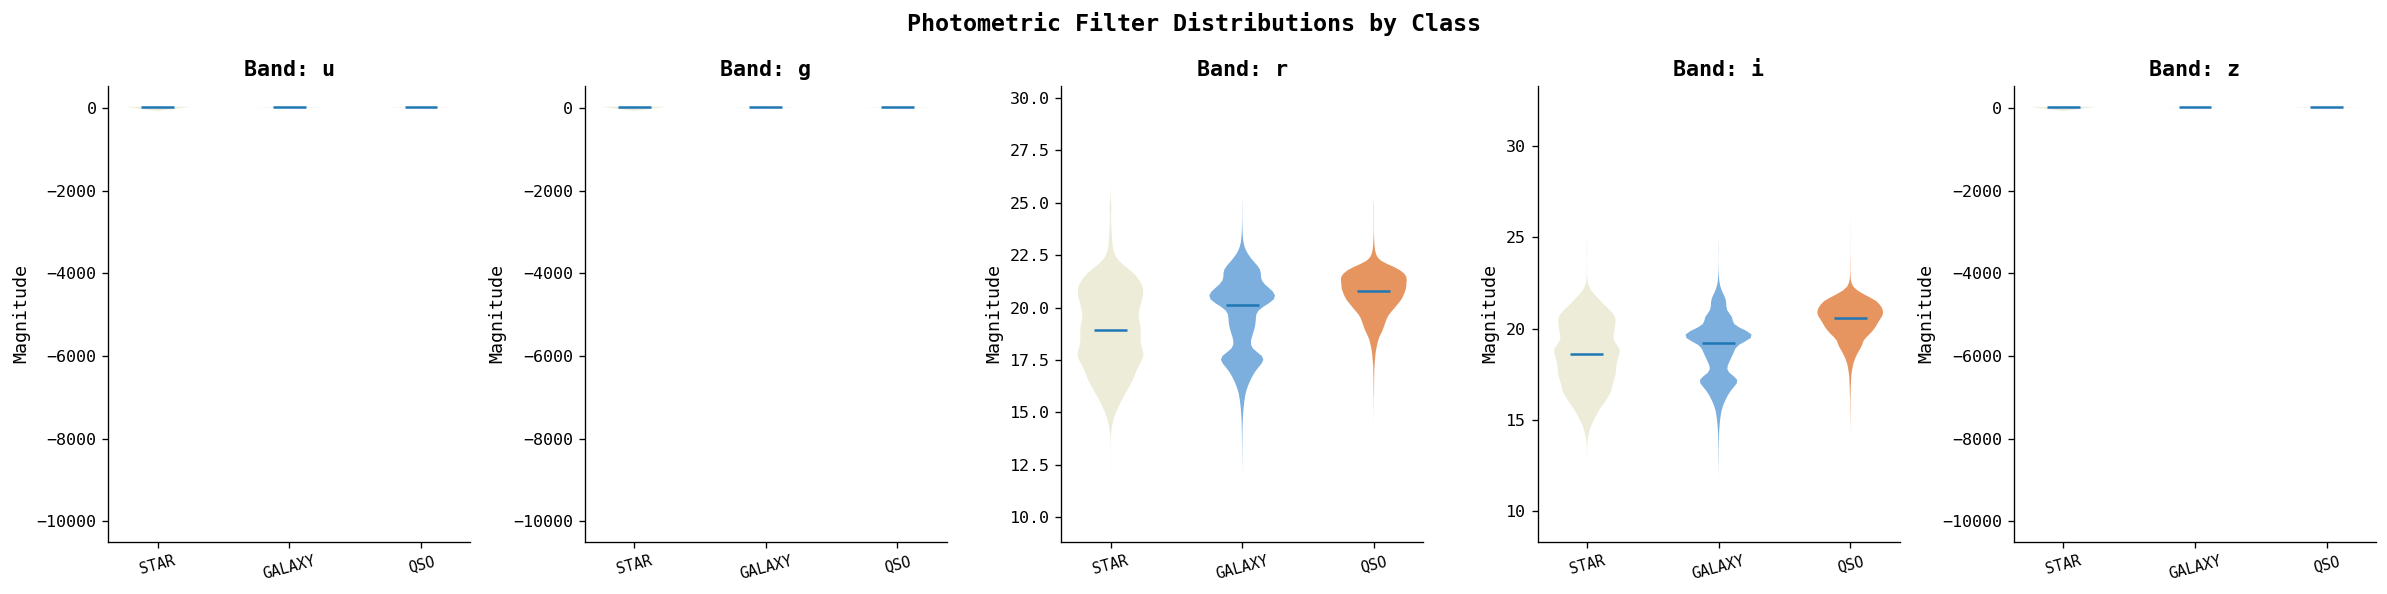

In [71]:
filters = ['u', 'g', 'r', 'i', 'z']
classes = ['STAR', 'GALAXY', 'QSO']  # ← исправлено

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)

for ax, band in zip(axes, filters):
    data = [df[df['class'] == cls][band].values for cls in classes]
    vp = ax.violinplot(data, positions=[0, 1, 2], showmedians=True, showextrema=False)
    for patch, cls in zip(vp['bodies'], classes):
        patch.set_facecolor(PALETTE[cls])
        patch.set_alpha(0.8)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(classes, rotation=15, fontsize=9)
    ax.set_title(f'Band: {band}', fontweight='bold')
    ax.set_ylabel('Magnitude')

plt.suptitle('Photometric Filter Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_02_violin_filters.png', bbox_inches='tight')
plt.show()

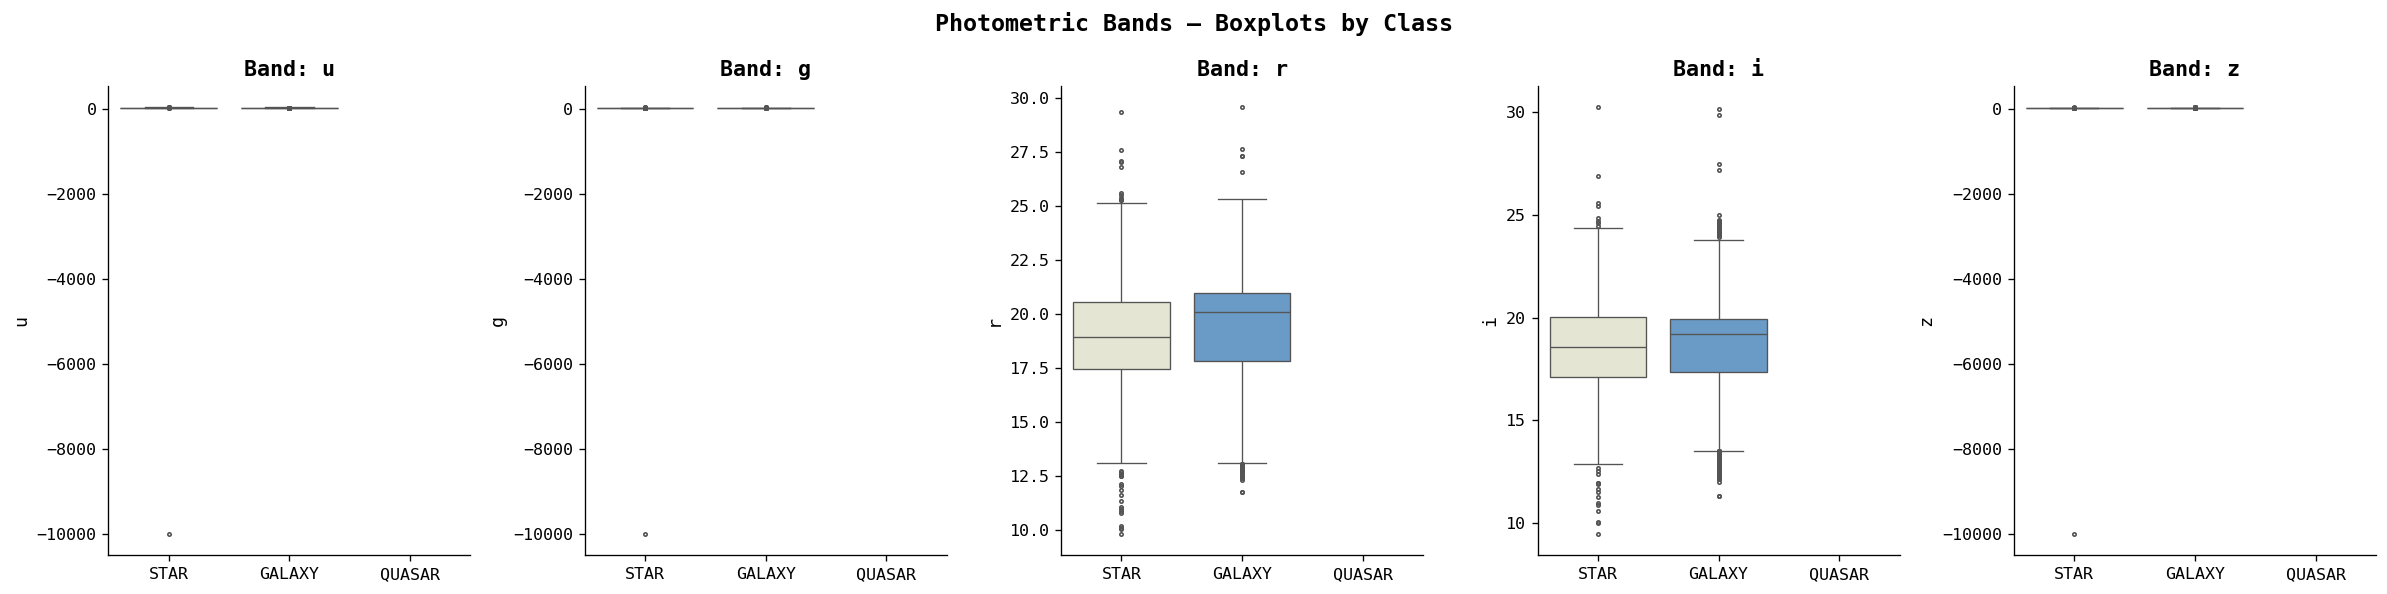

In [73]:
# Boxplots — easier to compare medians and outliers
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, band in zip(axes, filters):
    sns.boxplot(data=df, x='class', y=band, ax=ax,
                palette=PALETTE, order=['STAR', 'GALAXY', 'QUASAR'],
                linewidth=0.8, fliersize=2)
    ax.set_title(f'Band: {band}', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Photometric Bands — Boxplots by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_03_boxplots_filters.png', bbox_inches='tight')
plt.show()

**Observation:** *(опиши, какие фильтры лучше всего разделяют классы, где есть перекрытие)*

---
## 5. Redshift Analysis

**Redshift** measures how much the light from an object has been stretched
by the expansion of the universe. Nearby objects have redshift ≈ 0;
distant quasars can have redshift > 5.

This is expected to be the single most powerful predictor in our dataset.
Stars are local (redshift ≈ 0), galaxies are moderate, and quasars are distant
and fast-moving — producing very high redshift values.

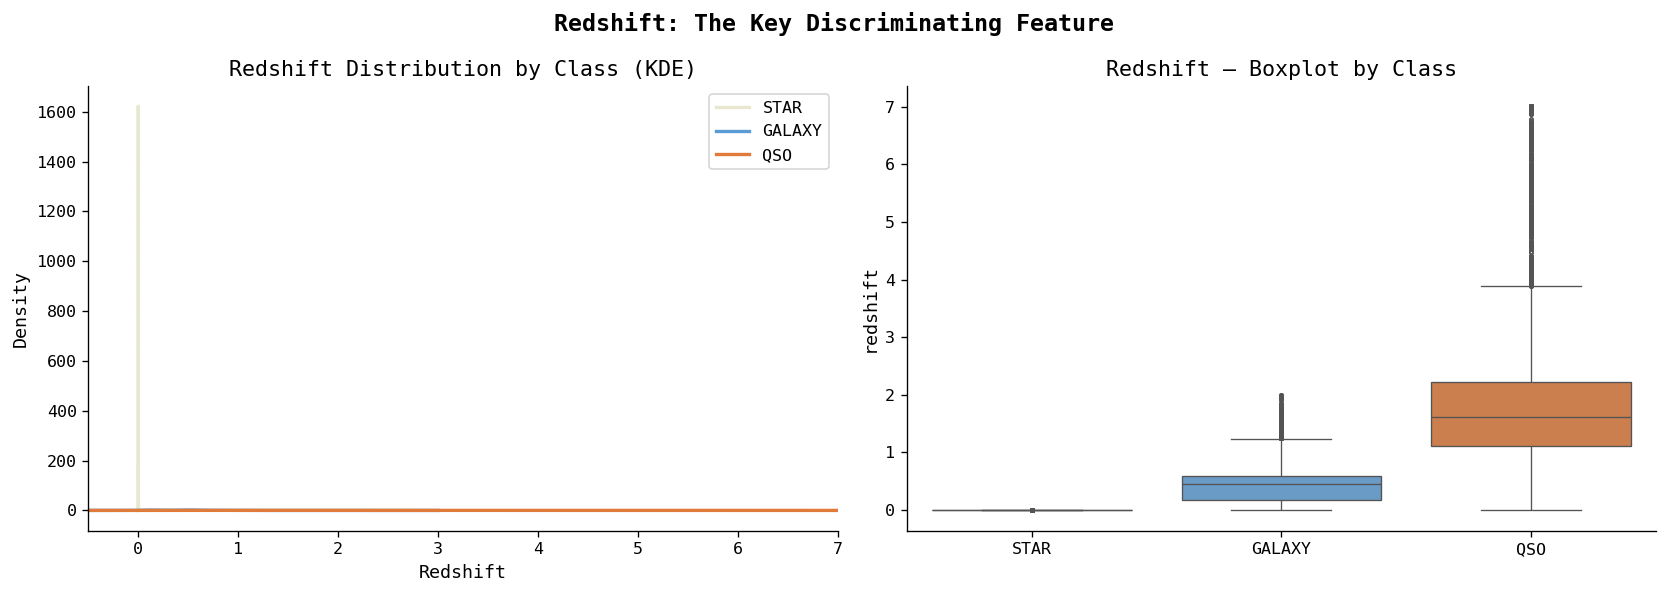

[2026-04-20 15:11:42] [INFO] Redshift stats per class:
[2026-04-20 15:11:42] [INFO]           count      mean       std       min       25%       50%       75%  \
class                                                                         
GALAXY  59445.0  0.421596  0.264858 -0.009971  0.164527  0.456274  0.594699   
QSO     18961.0  1.719676  0.913954  0.000461  1.106605  1.617232  2.220279   
STAR    21594.0 -0.000115  0.000465 -0.004136 -0.000295 -0.000076  0.000075   

             max  
class             
GALAXY  1.995524  
QSO     7.011245  
STAR    0.004153  


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,59445.000000,0.421596,0.264858,-0.009971,0.164527,0.456274,0.594699,1.995524
QSO,18961.000000,1.719676,0.913954,0.000461,1.106605,1.617232,2.220279,7.011245
STAR,21594.000000,-0.000115,0.000465,-0.004136,-0.000295,-0.000076,0.000075,0.004153


In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot by class
for cls in ['STAR', 'GALAXY', 'QSO']:
    subset = df[df['class'] == cls]['redshift']
    subset.plot.kde(ax=axes[0], label=cls, color=PALETTE[cls], linewidth=2)
axes[0].set_title('Redshift Distribution by Class (KDE)')
axes[0].set_xlabel('Redshift')
axes[0].set_xlim(-0.5, 7)
axes[0].legend()

# Boxplot
sns.boxplot(data=df, x='class', y='redshift', ax=axes[1],
            palette=PALETTE, order=['STAR', 'GALAXY', 'QSO'],
            linewidth=0.8, fliersize=2)
axes[1].set_title('Redshift — Boxplot by Class')
axes[1].set_xlabel('')

plt.suptitle('Redshift: The Key Discriminating Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_04_redshift.png', bbox_inches='tight')
plt.show()

logger.info('Redshift stats per class:')
logger.info(str(df.groupby('class')['redshift'].describe()))
df.groupby('class')['redshift'].describe().style.background_gradient(cmap='Oranges')

**Observation:** *(опиши распределение redshift по классам — это ключевой инсайт EDA)*

---
## 6. Feature Correlations

High correlations between features (multicollinearity) can affect model interpretability.
We expect the photometric bands `u, g, r, i, z` to be strongly correlated with each other,
since they all measure brightness — just at different wavelengths.

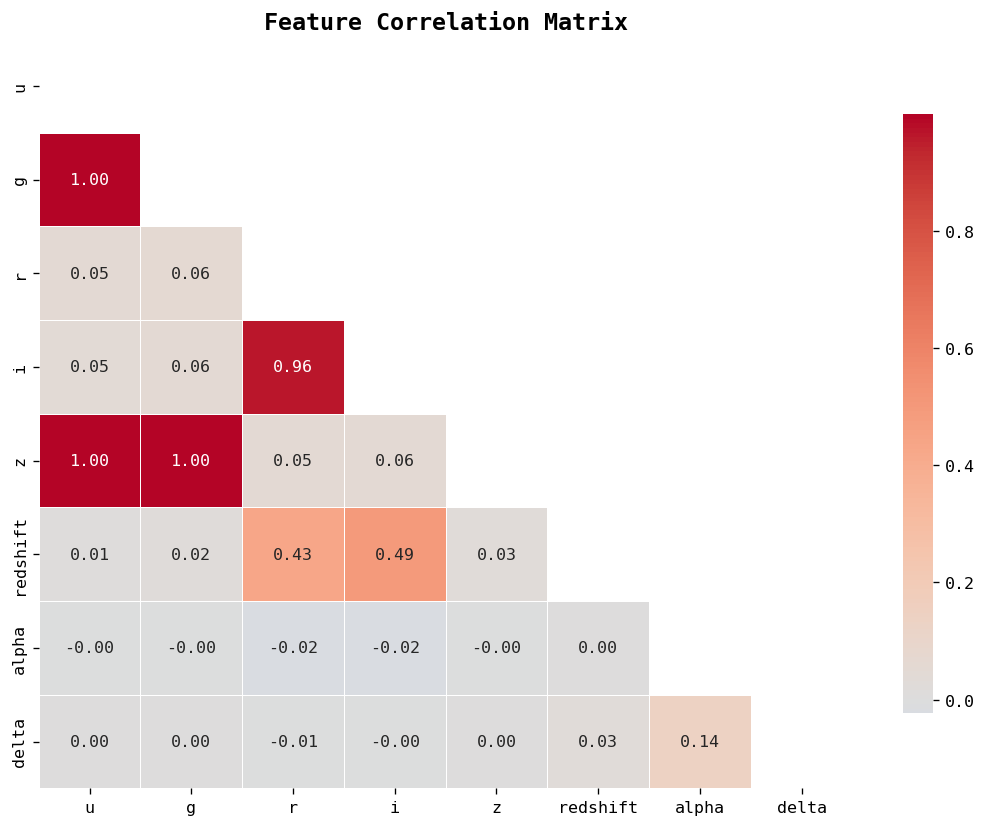

In [80]:
numeric_cols = ['u', 'g', 'r', 'i', 'z', 'redshift', 'alpha', 'delta']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_05_correlation_matrix.png', bbox_inches='tight')
plt.show()

**Observation:** *(опиши какие признаки сильно коррелируют и что это значит для модели)*

---
## 7. Colour Diagrams

In astrophotometry, **colour indices** (differences between filter magnitudes)
are a standard tool for object classification. The `u−g` and `g−r` indices
are particularly diagnostic. Plotting them against each other creates a
**colour-colour diagram** — the astronomer's version of a scatter plot.

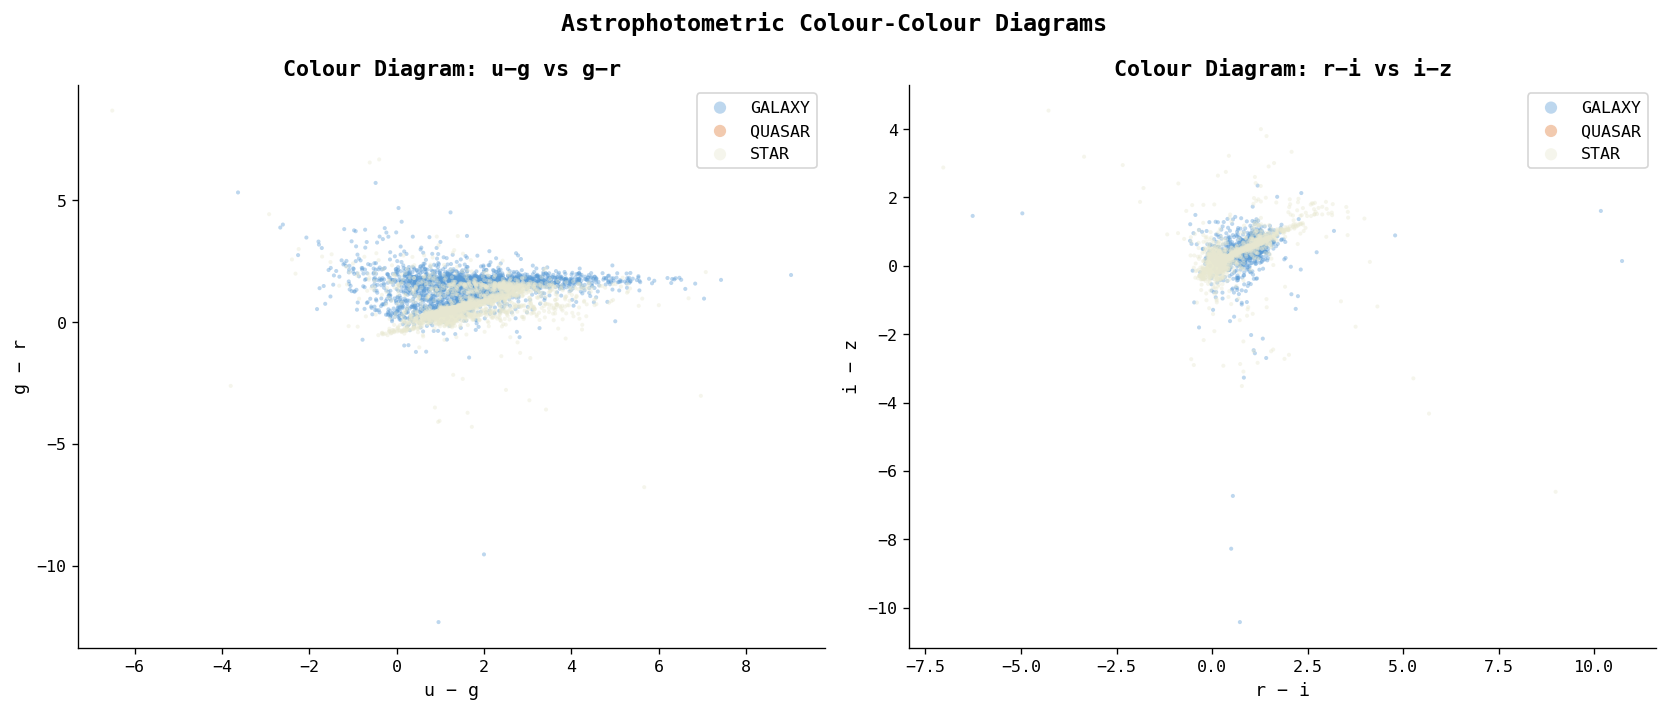

In [82]:
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cls in ['GALAXY', 'QUASAR', 'STAR']:  # order matters for visibility
    subset = df[df['class'] == cls].sample(min(3000, len(df[df['class']==cls])), random_state=42)
    axes[0].scatter(subset['u_g'], subset['g_r'], c=PALETTE[cls],
                    label=cls, alpha=0.4, s=6, edgecolors='none')
    axes[1].scatter(subset['r_i'], subset['i_z'], c=PALETTE[cls],
                    label=cls, alpha=0.4, s=6, edgecolors='none')

for ax, xlabel, ylabel, title in zip(
    axes,
    ['u − g', 'r − i'],
    ['g − r', 'i − z'],
    ['Colour Diagram: u−g vs g−r', 'Colour Diagram: r−i vs i−z']
):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(markerscale=3)

plt.suptitle('Astrophotometric Colour-Colour Diagrams', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_06_colour_diagrams.png', bbox_inches='tight')
plt.show()

**Observation:** *(опиши, видны ли чёткие кластеры классов в пространстве цветовых индексов)*

---
## 8. Sky Coverage Map

The coordinates `alpha` (right ascension) and `delta` (declination) define
where on the sky each object was observed. Plotting them reveals the survey
footprint of SDSS DR17 — the actual patches of sky that were imaged.

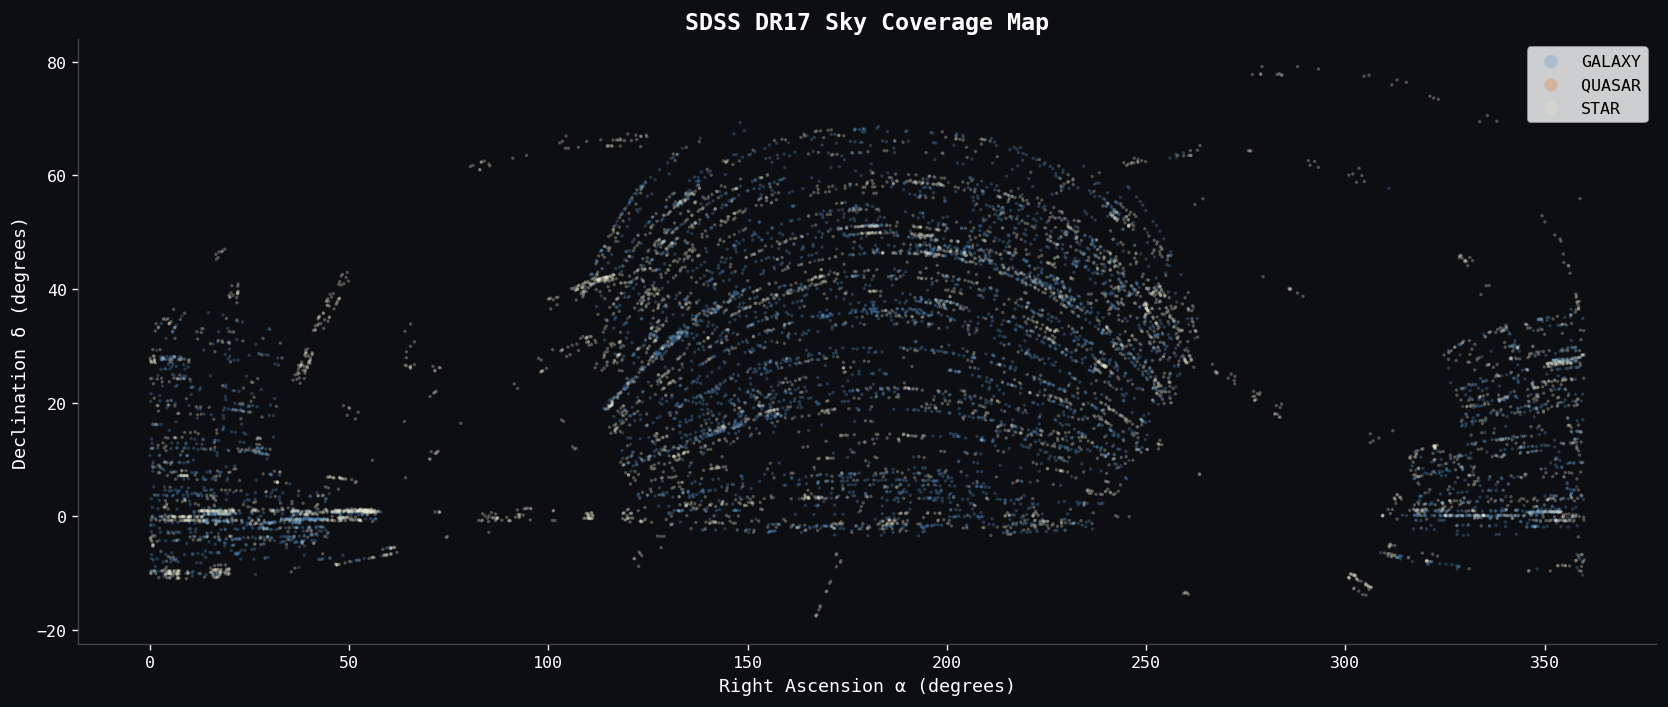

In [84]:
fig, ax = plt.subplots(figsize=(14, 6))

for cls in ['GALAXY', 'QUASAR', 'STAR']:
    subset = df[df['class'] == cls].sample(min(5000, len(df[df['class']==cls])), random_state=42)
    ax.scatter(subset['alpha'], subset['delta'],
               c=PALETTE[cls], label=cls, alpha=0.3, s=4, edgecolors='none')

ax.set_xlabel('Right Ascension α (degrees)')
ax.set_ylabel('Declination δ (degrees)')
ax.set_title('SDSS DR17 Sky Coverage Map', fontsize=14, fontweight='bold')
ax.legend(markerscale=4)
ax.set_facecolor('#0d0e12')
fig.patch.set_facecolor('#0d0e12')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_07_sky_map.png', bbox_inches='tight')
plt.show()


---
## 9. Dimensionality Reduction — t-SNE & UMAP

t-SNE and UMAP reduce high-dimensional feature spaces to 2D for visual inspection.
We run two versions: **with** and **without** `redshift`.
This directly previews the core experiment of the project:
how separable are the classes when redshift is removed?

> ⚠️ t-SNE and UMAP are slow on 100K rows. We sample 8,000 objects for visualisation.

[2026-04-20 15:16:57] [INFO] Running t-SNE with redshift...
[2026-04-20 15:17:07] [INFO] Running t-SNE without redshift...


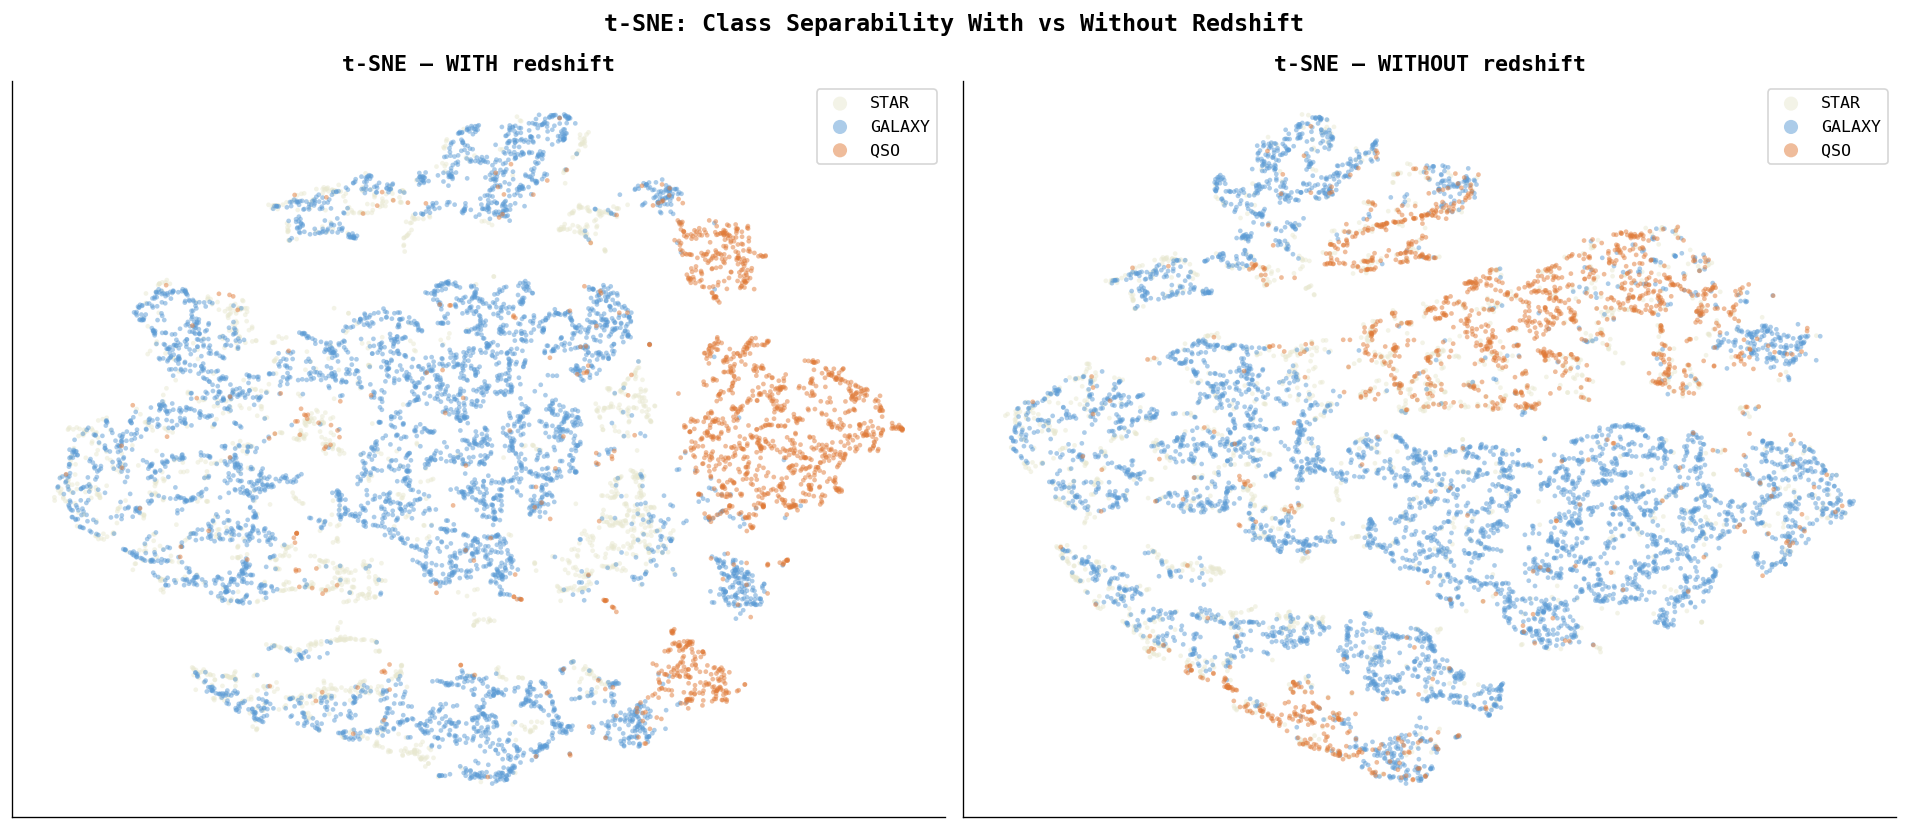

[2026-04-20 15:17:18] [INFO] t-SNE complete


In [86]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

SAMPLE_N = 8000
sample_df = df.sample(SAMPLE_N, random_state=42)

features_with = ['u', 'g', 'r', 'i', 'z', 'alpha', 'delta', 'redshift']
features_without = ['u', 'g', 'r', 'i', 'z', 'alpha', 'delta']

X_with = StandardScaler().fit_transform(sample_df[features_with])
X_without = StandardScaler().fit_transform(sample_df[features_without])

logger.info('Running t-SNE with redshift...')
tsne_with = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=500).fit_transform(X_with)
logger.info('Running t-SNE without redshift...')
tsne_without = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=500).fit_transform(X_without)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coords, title in zip(
    axes,
    [tsne_with, tsne_without],
    ['t-SNE — WITH redshift', 't-SNE — WITHOUT redshift']
):
    for cls in ['STAR', 'GALAXY', 'QSO']:
        mask = sample_df['class'].values == cls
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=PALETTE[cls], label=cls, alpha=0.5, s=8, edgecolors='none')
    ax.set_title(title, fontweight='bold')
    ax.legend(markerscale=3)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('t-SNE: Class Separability With vs Without Redshift',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_08_tsne.png', bbox_inches='tight')
plt.show()
logger.info('t-SNE complete')

[2026-04-20 15:20:35] [INFO] Running UMAP with redshift...
[2026-04-20 15:20:47] [INFO] Running UMAP without redshift...


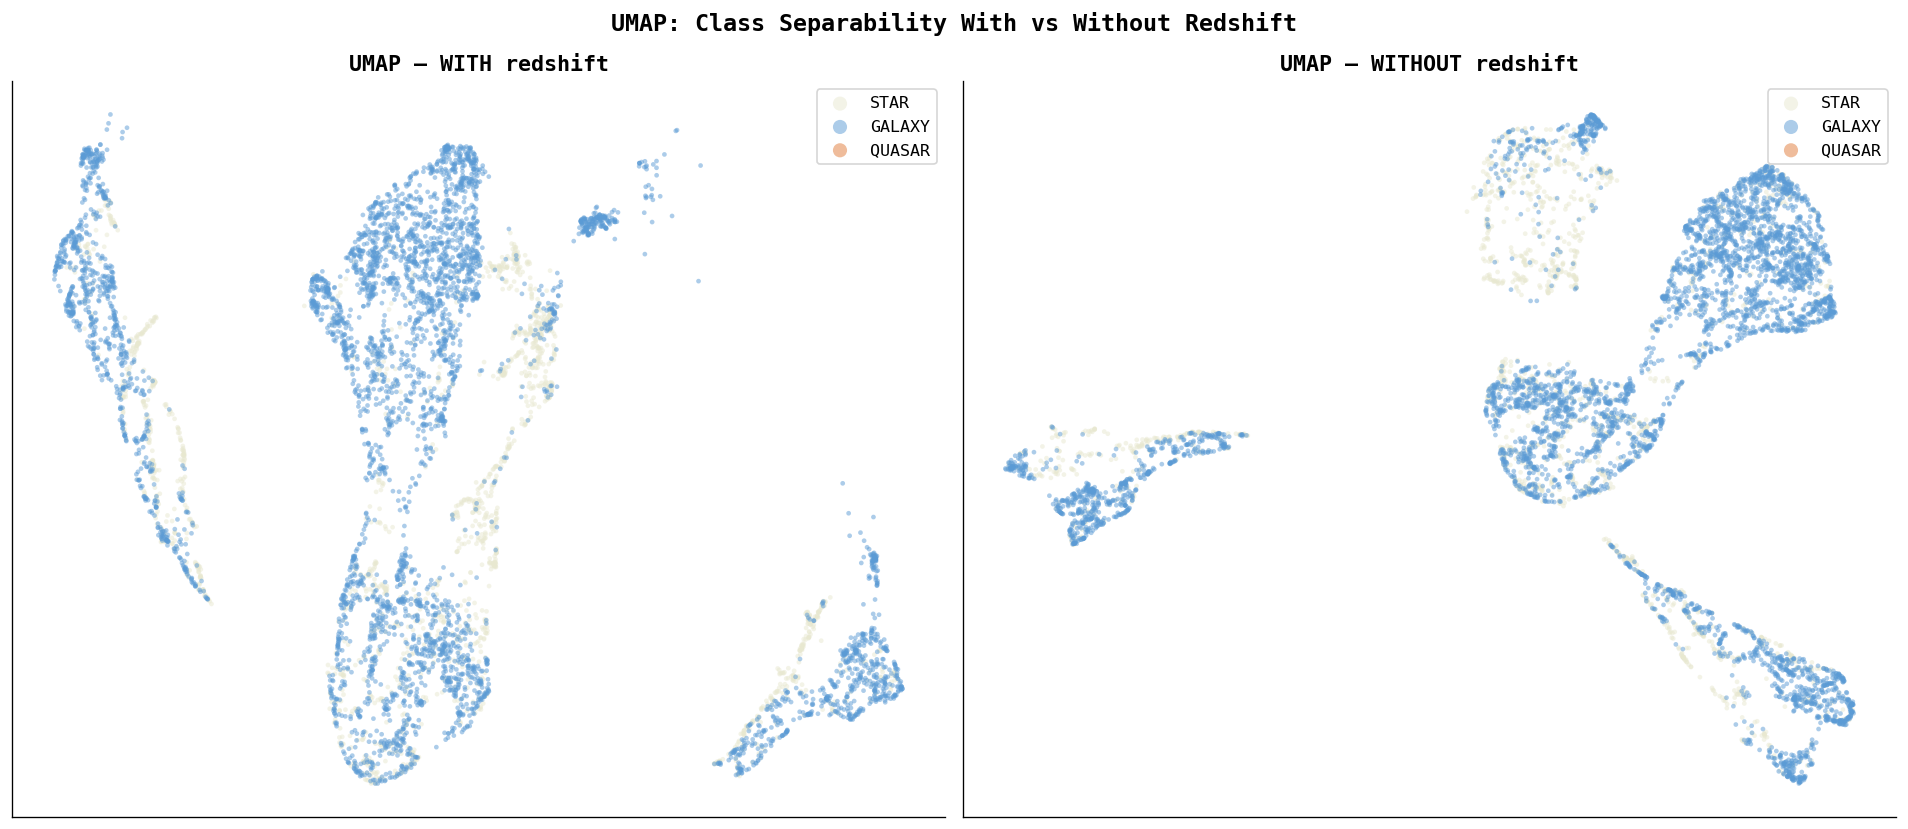

[2026-04-20 15:20:59] [INFO] UMAP complete


In [89]:
# UMAP — usually faster and better at preserving global structure
try:
    import umap
    logger.info('Running UMAP with redshift...')
    umap_with = umap.UMAP(n_components=2, random_state=42).fit_transform(X_with)
    logger.info('Running UMAP without redshift...')
    umap_without = umap.UMAP(n_components=2, random_state=42).fit_transform(X_without)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, coords, title in zip(
        axes,
        [umap_with, umap_without],
        ['UMAP — WITH redshift', 'UMAP — WITHOUT redshift']
    ):
        for cls in ['STAR', 'GALAXY', 'QUASAR']:
            mask = sample_df['class'].values == cls
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       c=PALETTE[cls], label=cls, alpha=0.5, s=8, edgecolors='none')
        ax.set_title(title, fontweight='bold')
        ax.legend(markerscale=3)
        ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle('UMAP: Class Separability With vs Without Redshift',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eda_09_umap.png', bbox_inches='tight')
    plt.show()
    logger.info('UMAP complete')
except ImportError:
    print('umap-learn not installed. Run: pip install umap-learn')
    logger.warning('umap-learn not available, skipping UMAP')



**Observation:** *(сравни оба графика — насколько хуже разделяются классы без redshift?
Это визуальное доказательство вашего главного эксперимента)*

---
## 10. EDA Conclusions & Hypotheses for Modelling

*(Заполни после запуска всех ячеек. Структура для вдохновения:)*

### Key Findings
- **Class balance:** ...
- **Redshift:** ...
- **Photometric bands:** ...
- **Colour indices:** ...
- **t-SNE / UMAP:** ...

### Hypotheses for Modelling
1. `redshift` will be the dominant feature in Random Forest feature importance
2. Without `redshift`, model accuracy is expected to drop significantly for **quasars**,
   since low-redshift quasars resemble compact galaxies photometrically
3. High collinearity between `u, g, r, i, z` suggests StandardScaler is necessary
   and dimensionality reduction might not hurt performance

### Output files saved to `backend/output/`
- `eda_01_class_distribution.png`
- `eda_02_violin_filters.png`
- `eda_03_boxplots_filters.png`
- `eda_04_redshift.png`
- `eda_05_correlation_matrix.png`
- `eda_06_colour_diagrams.png`
- `eda_07_sky_map.png`
- `eda_08_tsne.png`
- `eda_09_umap.png`